In [73]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay
import statsmodels.api as sm
import statsmodels.formula.api as smf
from pathlib import Path

In [74]:
df=pd.read_csv('data/df_limpio.csv')
df.head()


,ID,Edad,Ingresos,Monto_Inicial,Scoring_Crediticio,Meses_Empleo,Num_Creditos,Ratio_Interes,Duracion,Ratio_Deuda_Ingresos,Estudios,Tipo_Jornada_Laboral,Estado_Civil,Posesion_Hipoteca,Personas_Cargo,Proposito,Fiador,Impago,Prima
0,6B4H6E,22,16000.0,10000,769,22.0,1,8.96,48.0,0.32,Escolar,Desempleado,Soltero,1.0,1.0,Vivienda,0.0,0,65.85
1,VKTUXP,33,38308.0,16474,699,70.0,3,14.07,36.0,0.20,Máster,Jornada completa,Casado,1.0,1.0,Vivienda,0.0,0,260.60
2,5P9OVL,51,51271.0,40770,812,309.0,1,12.66,12.0,0.36,Grado Universitario,Jornada completa,Casado,0.0,1.0,Vivienda,1.0,0,221.02
3,YL0W8G,30,31923.0,36707,813,43.0,1,8.96,24.0,0.32,Grado Universitario,Jornada completa,Casado,0.0,1.0,Vivienda,0.0,0,125.00
4,YP8WTV,28,27373.0,86981,765,60.0,2,10.07,48.0,0.55,Escolar,Jornada completa,Soltero,0.0,1.0,Vivienda,0.0,0,800.00


In [75]:
copy=df.copy()
# hacemos copia por si acaso queremos ver la forma original en algun momento

In [76]:
copy.dtypes

ID                          str
Edad                      int64
Ingresos                float64
Monto_Inicial             int64
Scoring_Crediticio        int64
Meses_Empleo            float64
Num_Creditos              int64
Ratio_Interes           float64
Duracion                float64
Ratio_Deuda_Ingresos    float64
Estudios                    str
Tipo_Jornada_Laboral        str
Estado_Civil                str
Posesion_Hipoteca       float64
Personas_Cargo          float64
Proposito                   str
Fiador                  float64
Impago                    int64
Prima                   float64
dtype: object

In [77]:
copy["Tipo_Jornada_Laboral"].unique()

<StringArray>
['Desempleado', 'Jornada completa', 'Tiempo parcial', 'Autónomo']
Length: 4, dtype: str

In [78]:
copy["Estado_Civil"].unique()

<StringArray>
['Soltero', 'Casado', 'Divorciado']
Length: 3, dtype: str

In [79]:
copy["Estudios"].unique()

<StringArray>
['Escolar', 'Máster', 'Grado Universitario', 'Doctorado']
Length: 4, dtype: str

MODELO: regresión logística ya que tenemos valores binarios (0: no impago, 1: impago)

In [80]:
# variables en escalas muy diferentes, asi que escalar. 
# variables no numéricas--> pasar a numérico (probar si una tiene mas peso que otra y usar ordinal enc, si no one hot)

In [81]:
num=copy.drop(columns=["Estudios", "Tipo_Jornada_Laboral", "Estado_Civil","ID","Proposito"])

<Axes: >

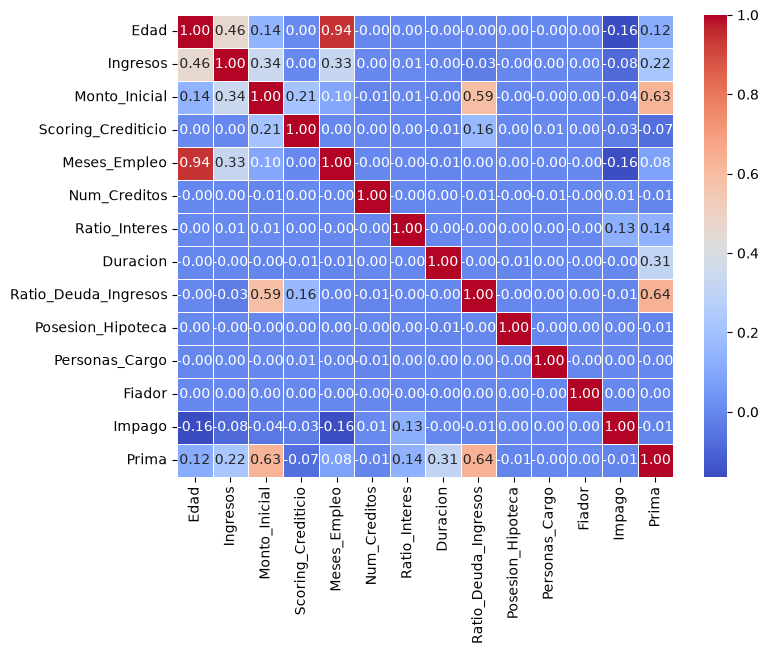

In [82]:
matriz_corr =num.corr(numeric_only=True)

# Crear la figura
plt.figure(figsize=(8, 6))

# Dibujar el mapa de calor
sns.heatmap(matriz_corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

In [83]:
copy.groupby("Estado_Civil")["Impago"].mean()

Estado_Civil
Casado        0.098282
Divorciado    0.077275
Soltero       0.167024
Name: Impago, dtype: float64

In [84]:
copy["Estado_Civil"].value_counts()

Estado_Civil
Casado        52146
Soltero       30756
Divorciado    18997
Name: count, dtype: int64

In [85]:
copy.groupby("Tipo_Jornada_Laboral")["Impago"].mean()  #aqui no existe una jerarquia

Tipo_Jornada_Laboral
Autónomo            0.118491
Desempleado         0.118453
Jornada completa    0.114570
Tiempo parcial      0.112467
Name: Impago, dtype: float64

In [86]:
copy.groupby("Estudios")["Impago"].mean() 

Estudios
Doctorado              0.117589
Escolar                0.102644
Grado Universitario    0.124974
Máster                 0.121298
Name: Impago, dtype: float64

In [87]:
# en estudios y jornada no tiene sentido poner un orden, la tasa de impago es muy parecida

In [88]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_enc=OrdinalEncoder(categories=[["Divorciado", "Casado", "Soltero"]])

copy[["Estado_Civil"]] = ordinal_enc.fit_transform(copy[["Estado_Civil"]])

In [89]:
copy  #df con el ordinal encoder hecho.

,ID,Edad,Ingresos,Monto_Inicial,Scoring_Crediticio,Meses_Empleo,Num_Creditos,Ratio_Interes,Duracion,Ratio_Deuda_Ingresos,Estudios,Tipo_Jornada_Laboral,Estado_Civil,Posesion_Hipoteca,Personas_Cargo,Proposito,Fiador,Impago,Prima
0,6B4H6E,22,16000.0,10000,769,22.0,1,8.96,48.0,0.32,Escolar,Desempleado,2.0,1.0,1.0,Vivienda,0.0,0,65.85
1,VKTUXP,33,38308.0,16474,699,70.0,3,14.07,36.0,0.20,Máster,Jornada completa,1.0,1.0,1.0,Vivienda,0.0,0,260.60
2,5P9OVL,51,51271.0,40770,812,309.0,1,12.66,12.0,0.36,Grado Universitario,Jornada completa,1.0,0.0,1.0,Vivienda,1.0,0,221.02
3,YL0W8G,30,31923.0,36707,813,43.0,1,8.96,24.0,0.32,Grado Universitario,Jornada completa,1.0,0.0,1.0,Vivienda,0.0,0,125.00
4,YP8WTV,28,27373.0,86981,765,60.0,2,10.07,48.0,0.55,Escolar,Jornada completa,2.0,0.0,1.0,Vivienda,0.0,0,800.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101894,5PM51H,29,35671.0,5681,628,27.0,2,12.11,48.0,0.10,Grado Universitario,Jornada completa,2.0,0.0,1.0,Vivienda,1.0,0,116.89
101895,L0RUJT,28,22864.0,40000,752,9.0,2,10.77,48.0,0.55,Grado Universitario,Jornada completa,1.0,0.0,1.0,Vivienda,0.0,0,607.55
101896,8OJZU0,35,69159.0,41795,699,65.0,2,10.41,36.0,0.29,Doctorado,Tiempo parcial,2.0,0.0,0.0,Vivienda,0.0,0,406.82
101897,II8B24,39,68375.0,21847,722,170.0,2,6.26,36.0,0.14,Máster,Jornada completa,1.0,0.0,1.0,Vivienda,1.0,0,125.32


In [ ]:
# las otras dos categóricas, con one-hot